### Importing libraries

In [1]:
import os
import cupy as cp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import neo
from scipy.signal import butter, filtfilt, hilbert, iirnotch, welch, find_peaks
from scipy.integrate import trapezoid
from scipy.fft import fft, ifft
import pywt


c:\Users\laboratorio\anaconda3\envs\lfp-env\Lib\site-packages\cupy\_environment.py:286: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


### Setup and Load Data using Neo (BlackrockIO)

In [2]:
# Directory and file configuration
data_dir = "C:\\Users\\laboratorio\\Downloads"
filename = "20230522-090311-001.ns2"
file_path = os.path.join(data_dir, filename)

if not os.path.exists(file_path):
    raise FileNotFoundError(f"The file {filename} was not found in {data_dir}")

# Load continuous data using Neo BlackrockIO reader
reader = neo.io.BlackrockIO(file_path)
block = reader.read_block()
analog_signal = block.segments[0].analogsignals[0]

# Extract basic properties
fs = int(analog_signal.sampling_rate)  
num_channels = analog_signal.shape[1]

# Transfer data to GPU using CuPy and transpose to get (channels, samples)
signal_data_gpu = cp.array(analog_signal).T
signal_data_cpu = np.array(analog_signal).T

channel_ids = np.asarray(analog_signal.array_annotations['channel_ids']).astype(str)
channel_names = [f'CH_{channel_id}' for channel_id in channel_ids]
channel_id_to_index = {
    channel_id: index for index, channel_id in enumerate(channel_ids)
}

if len(channel_ids) != num_channels:
    raise ValueError('channel_ids does not match the number of signal channels.')

print(f"File loaded successfully: {filename}")
print(f"Sampling Frequency (fs): {fs} Hz")
print(f"Number of Channels: {num_channels}")
print(f"Channel IDs: {', '.join(channel_ids)}")
print(f"Total Samples: {signal_data_gpu.shape[1]}")

File loaded successfully: 20230522-090311-001.ns2
Sampling Frequency (fs): 1000 Hz
Number of Channels: 39
Channel IDs: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39
Total Samples: 1810010


### Baseline Data Exploration and Descriptive Statistics

In [3]:
# Explore a 10-second window starting at minute 6.
start_time = 6 * 60
window_seconds = 10
start_sample = int(start_time * fs)
end_sample = min(start_sample + int(window_seconds * fs), signal_data_gpu.shape[1])

if start_sample >= signal_data_gpu.shape[1]:
    raise ValueError('The recording is shorter than the selected start time.')

time_array_cpu = np.arange(start_sample, end_sample) / fs
signal_segment_cpu = cp.asnumpy(signal_data_gpu[:, start_sample:end_sample].T)

df_exploration = pd.DataFrame(signal_segment_cpu, columns=channel_names)
df_exploration.insert(0, 'Time (s)', time_array_cpu)
df_exploration.set_index('Time (s)', inplace=True)

print(f'Exploring recording window: {time_array_cpu[0]:.2f} to {time_array_cpu[-1]:.2f} s')
print('=== CHANNEL DATAFRAME PREVIEW ===')
display(df_exploration.head(10))

print('\n=== DATA DESCRIPTIVE STATISTICS (ALL CHANNELS) ===')
display(df_exploration.describe())

Exploring recording window: 360.00 to 370.00 s
=== CHANNEL DATAFRAME PREVIEW ===


,CH_1,CH_2,CH_3,CH_4,CH_5,CH_6,CH_7,CH_8,CH_9,CH_10,...,CH_30,CH_31,CH_32,CH_33,CH_34,CH_35,CH_36,CH_37,CH_38,CH_39
Time (s),,,,,,,,,,,,,,,,,,,,,
360.000,131.50,136.25,169.75,159.00,136.00,151.25,148.00,141.75,124.75,210.25,...,193.50,1749.00,24.25,-202.50,274.25,293.0,-5.0,657.25,36.50,-161.25
360.001,124.75,199.25,197.00,207.25,177.25,145.50,193.25,215.25,161.50,270.25,...,152.75,1501.75,107.25,-202.25,274.25,157.0,-5.0,708.75,10.50,-161.00
360.002,124.00,240.75,183.50,207.25,202.50,150.00,216.50,232.50,197.25,286.50,...,101.25,1235.00,122.25,-184.25,360.25,157.0,-5.0,708.75,10.50,-143.75
360.003,130.25,255.75,265.75,251.25,242.75,177.50,250.25,272.50,247.50,321.50,...,86.75,889.00,161.00,-184.25,360.25,39.0,-13.0,767.50,-13.50,-143.75
360.004,113.75,267.75,247.50,269.00,247.00,162.50,257.25,270.75,235.50,340.50,...,68.00,616.25,192.75,-216.25,430.00,39.0,-13.0,767.50,-13.50,-242.00
360.005,124.75,295.50,319.75,292.50,257.00,136.50,275.00,308.25,263.00,389.50,...,38.75,528.25,240.75,-216.25,430.00,28.0,-5.0,814.75,-62.25,-242.00
360.006,110.75,261.00,279.25,276.00,247.00,142.25,267.00,280.00,258.25,386.75,...,61.25,762.00,251.00,-232.25,436.00,28.0,-5.0,814.50,-62.25,-448.00
360.007,120.50,226.00,258.25,238.00,232.00,145.75,238.50,247.25,237.50,365.00,...,113.75,1175.00,237.50,-232.00,436.00,101.0,-9.0,837.75,-37.50,-447.75
360.008,124.25,195.50,222.75,227.25,214.25,179.75,214.25,245.75,211.50,368.75,...,155.25,1428.50,172.00,-231.00,481.75,101.0,-9.0,837.50,-37.50,-450.75



=== DATA DESCRIPTIVE STATISTICS (ALL CHANNELS) ===


,CH_1,CH_2,CH_3,CH_4,CH_5,CH_6,CH_7,CH_8,CH_9,CH_10,...,CH_30,CH_31,CH_32,CH_33,CH_34,CH_35,CH_36,CH_37,CH_38,CH_39
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,-2.287150,-17.319851,31.651501,4.177375,-35.577126,-9.758525,-5.48650,-3.214650,-26.316175,-37.648449,...,-22.167974,22.381426,-5.107650,-52.513550,-25.895201,-29.253475,-14.114425,20.161825,-30.709925,-13.057800
std,574.817688,615.846375,623.122375,610.812012,606.383179,571.107788,594.26416,591.935913,592.890991,594.865906,...,528.477234,1029.156616,598.935669,203.049103,800.325745,311.101227,10.184924,496.134552,237.281967,805.925354
min,-1469.500000,-1722.250000,-1661.250000,-1688.750000,-1699.000000,-1502.000000,-1677.75000,-1684.000000,-1693.250000,-1715.750000,...,-1795.250000,-3569.250000,-1584.500000,-610.750000,-3586.000000,-1113.250000,-51.500000,-1637.750000,-1150.750000,-2766.250000
25%,-345.312500,-385.750000,-352.000000,-367.562500,-409.250000,-361.250000,-374.81250,-372.000000,-392.562500,-393.312500,...,-334.562500,-630.750000,-374.062500,-198.000000,-446.500000,-234.562500,-21.000000,-217.312500,-155.750000,-448.000000
50%,-14.875000,-29.125000,-19.250000,-22.875000,-26.750000,-11.750000,-16.25000,-18.250000,-21.750000,-34.125000,...,-5.250000,-54.625000,-21.750000,-88.625000,143.750000,-20.250000,-13.250000,49.500000,-22.500000,59.000000
75%,285.250000,316.375000,364.062500,338.000000,299.750000,270.000000,322.75000,324.062500,299.812500,287.250000,...,266.250000,641.312500,323.750000,71.000000,546.500000,171.250000,-6.250000,280.750000,98.000000,532.000000
max,1771.750000,1922.750000,1988.000000,1909.000000,1835.000000,1719.250000,1845.50000,1842.750000,1764.000000,1801.250000,...,1579.250000,3622.750000,1848.750000,727.750000,1553.000000,1272.250000,31.000000,2095.000000,1179.000000,1909.000000


### Auxiliar channels analysis

In [4]:
print("=== AnalogSignal ===")
print(analog_signal)

print("\n=== Annotations ===")
print(analog_signal.annotations)

print("\n=== Array annotations ===")
print(analog_signal.array_annotations)

print("\n=== Units ===")
print(analog_signal.units)

=== AnalogSignal ===
[[ 39.5   32.5  -11.25 ...  18.75  53.75 -28.25]
 [ 69.25   9.75 -32.5  ...  23.     0.5  -28.25]
 [ 55.75  28.5  -16.5  ...  23.     0.5   11.5 ]
 ...
 [-16.   -19.75   1.5  ...  23.25   2.    -9.75]
 [-24.25 -23.   -33.5  ...  -4.75   2.    -9.75]
 [-27.5  -27.25 -18.25 ...  -4.75  29.5    8.75]] uV

=== Annotations ===
{'stream_id': np.str_('2'), 'nsx': 2}

=== Array annotations ===
{'channel_names': array(['chan1', 'chan2', 'chan3', 'chan4', 'chan5', 'chan6', 'chan7',
       'chan8', 'chan9', 'chan10', 'chan11', 'chan12', 'chan13', 'chan14',
       'chan15', 'chan16', 'chan17', 'chan18', 'chan19', 'chan20',
       'chan21', 'chan22', 'chan23', 'chan24', 'chan25', 'chan26',
       'chan27', 'chan28', 'chan29', 'chan30', 'chan31', 'chan32',
       'chan33', 'chan34', 'chan35', 'chan36', 'chan37', 'chan38',
       'chan39'], dtype='<U6'), 'channel_ids': array(['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12',
       '13', '14', '15', '16', '17', '18',

In [5]:
for k, v in analog_signal.array_annotations.items():
    print(f"{k}: {v}")

channel_names: ['chan1' 'chan2' 'chan3' 'chan4' 'chan5' 'chan6' 'chan7' 'chan8' 'chan9'
 'chan10' 'chan11' 'chan12' 'chan13' 'chan14' 'chan15' 'chan16' 'chan17'
 'chan18' 'chan19' 'chan20' 'chan21' 'chan22' 'chan23' 'chan24' 'chan25'
 'chan26' 'chan27' 'chan28' 'chan29' 'chan30' 'chan31' 'chan32' 'chan33'
 'chan34' 'chan35' 'chan36' 'chan37' 'chan38' 'chan39']
channel_ids: ['1' '2' '3' '4' '5' '6' '7' '8' '9' '10' '11' '12' '13' '14' '15' '16'
 '17' '18' '19' '20' '21' '22' '23' '24' '25' '26' '27' '28' '29' '30'
 '31' '32' '33' '34' '35' '36' '37' '38' '39']
physical_connector: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2
 2 2]
connector_pin: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24
 25 26 27 28 29 30 31 32  1  2  3  4  5  6  7]
hi_freq_corner: [300 300 300 300 300 300 300 300 300 300 300 300 300 300 300 300 300 300
 300 300 300 300 300 300 300 300 300 300 300 300 300 300 300 300 300 300
 300 300 300]
lo_freq_corner: [75000

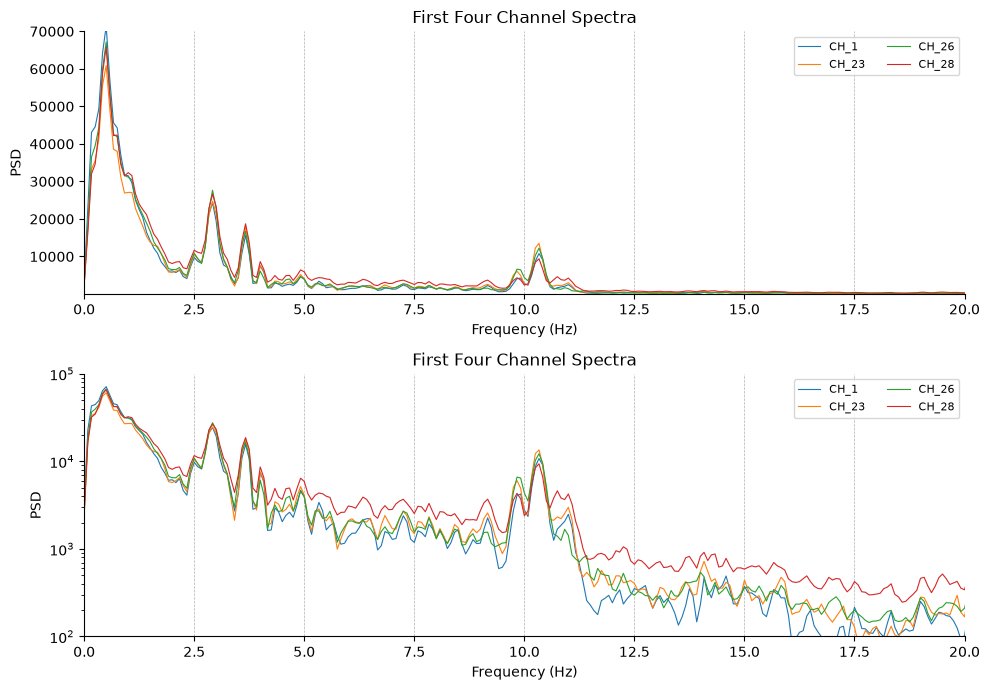

In [6]:
nperseg_val = int(fs * 12)
noverlap = int(nperseg_val / 2)         # 50% overlap


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))
channel_list = [0, 22, 25, 27]

for channel_index in channel_list:
    frequency, power = welch( signal_data_cpu[channel_index], fs=fs,
        nperseg=nperseg_val, noverlap=noverlap
    )
    ax1.plot( frequency, power, lw=0.8, label=channel_names[channel_index]
    )

ax1.set_xlim(0, 20)
ax1.set_ylim(1, 70000)
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('PSD')
ax1.set_title('First Four Channel Spectra')
ax1.spines[['top', 'right']].set_visible(False)
ax1.legend(ncol=2, fontsize=8)
ax1.grid(visible=True, axis='x', linestyle='--', linewidth=0.5)


for channel_index in channel_list:
    frequency, power = welch( signal_data_cpu[channel_index], fs=fs,
        nperseg=nperseg_val, noverlap=noverlap
    )
    ax2.semilogy(frequency, power, lw=0.8, label=channel_names[channel_index]
    )

ax2.set_xlim(0, 20)
ax2.set_ylim(1e2, 1e5)
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('PSD')
ax2.set_title('First Four Channel Spectra')
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(ncol=2, fontsize=8)
ax2.grid(visible=True, axis='x', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

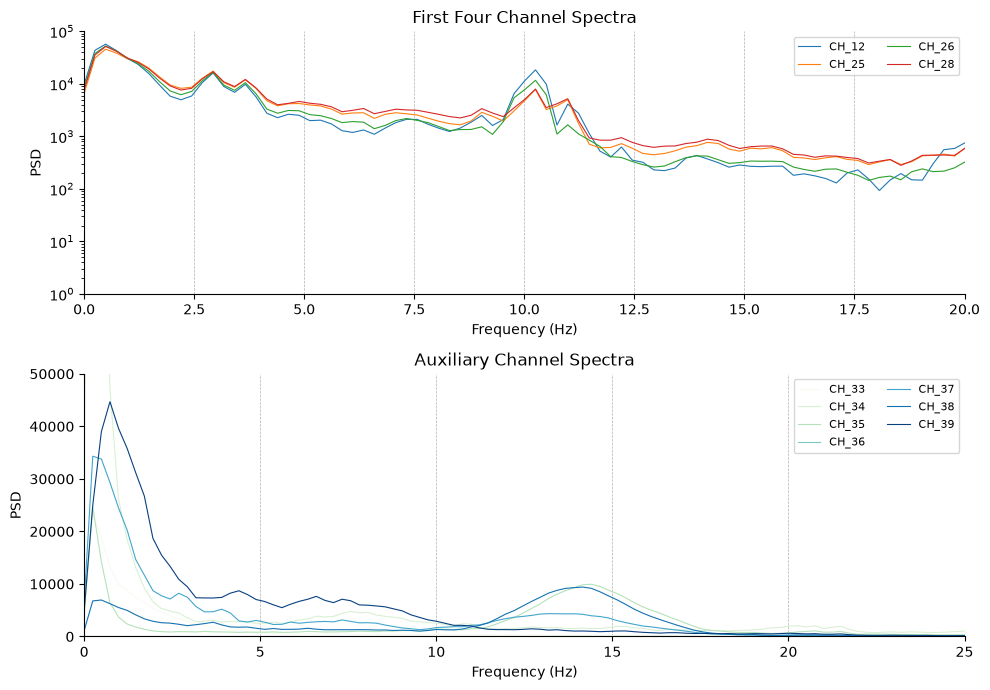

In [213]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 7))
channel_list = [12, 25, 26, 28]

for channel_index in channel_list:
    frequency, power = welch(
        signal_data_cpu[channel_index-1],
        fs=fs,
        nperseg=min(4096, signal_data_cpu.shape[1])
    )
    ax1.semilogy(
        frequency,
        power,
        lw=0.8,
        label=channel_names[channel_index-1]
    )

ax1.set_xlim(0, 20)
ax1.set_ylim(1, 10e4)
ax1.set_xlabel('Frequency (Hz)')
ax1.set_ylabel('PSD')
ax1.set_title('First Four Channel Spectra')
ax1.spines[['top', 'right']].set_visible(False)
ax1.legend(ncol=2, fontsize=8)
ax1.grid(visible=True, axis='x', linestyle='--', linewidth=0.5)

auxiliary_indices = np.arange(32, num_channels)
for plot_index, channel_index in enumerate(auxiliary_indices):
    frequency, power = welch(
        signal_data_cpu[channel_index],
        fs=fs,
        nperseg=min(4096, signal_data_cpu.shape[1])
    )
    ax2.plot(
        frequency,
        power,
        lw=0.8,
        label=channel_names[channel_index],
        color=plt.cm.GnBu(plot_index / max(1, len(auxiliary_indices) - 1))
    )

ax2.set_xlim(0, 25)
ax2.set_ylim(0, 5e4)
ax2.set_xticks(np.arange(0, 26, 5))
ax2.set_xlabel('Frequency (Hz)')
ax2.set_ylabel('PSD')
ax2.set_title('Auxiliary Channel Spectra')
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(ncol=2, fontsize=8)
ax2.grid(visible=True, axis='x', linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

In [ ]:
def bandpass(signal, low, high, fs, order=4):
    coefficients, denominator = butter(order, [low, high], btype='band', fs=fs)
    return filtfilt(coefficients, denominator, signal)

ripple = bandpass(signal_data_cpu[0], 80, 250, fs)

for channel_index in range(32, num_channels):
    correlation = np.corrcoef(ripple, signal_data_cpu[channel_index])[0, 1]
    print(f"{channel_names[channel_index]}: r = {correlation:.3f}")

CH_33: r = -0.001
CH_34: r = -0.001
CH_35: r = -0.002
CH_36: r = 0.000
CH_37: r = -0.000
CH_38: r = -0.001
CH_39: r = 0.002


In [8]:
from scipy.signal import coherence

for channel_index in range(32, num_channels):
    frequency, coherence_values = coherence(
        signal_data_cpu[0],
        signal_data_cpu[channel_index],
        fs=fs,
        nperseg=min(4096, signal_data_cpu.shape[1])
    )

    frequency_mask = (frequency >= 1) & (frequency <= min(300, fs / 2))
    print(
        f"{channel_names[channel_index]}: "
        f"max coherence = {coherence_values[frequency_mask].max():.3f}"
    )

CH_33: max coherence = 0.187
CH_34: max coherence = 0.457
CH_35: max coherence = 0.355
CH_36: max coherence = 0.010
CH_37: max coherence = 0.190
CH_38: max coherence = 0.256
CH_39: max coherence = 0.285


### LFP Stacked Overview (Strictly Channels 0 to 31)

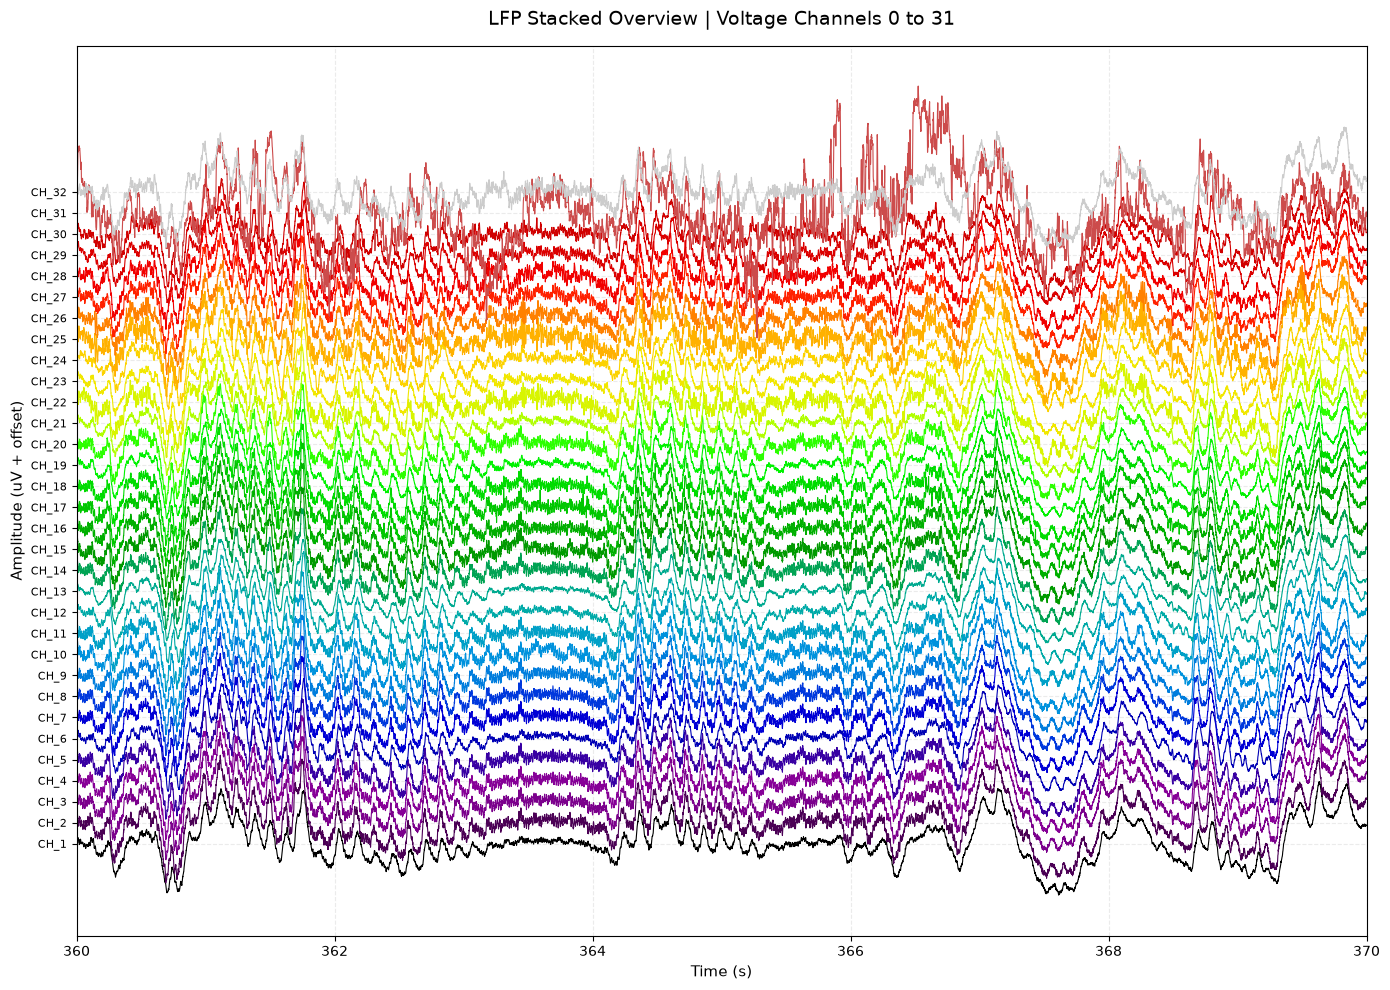

In [9]:
# --- Visualization: First 32 Voltage Channels Stacked ---
t_start, t_stop = 360.0, 370.0
n_plot_channels = 32  # Limited strictly to the 32 real voltage channels
offset_value = 600    # Adjust this value if traces overlap too much

# Slice time window and select only the first 32 channels from exploration DataFrame
df_lfp_real = df_exploration.iloc[:, :n_plot_channels]
df_window = df_lfp_real.loc[t_start:t_stop]

# Apply vertical offset to separate channels cleanly
offsets = np.arange(n_plot_channels) * offset_value
df_offset = df_window + offsets

# Plotting Configuration
fig, ax = plt.subplots(figsize=(14, 10))

# Use a continuous colormap to generate distinct colors for all 32 channels
colors = plt.cm.nipy_spectral(np.linspace(0, 1, n_plot_channels))

for i, col in enumerate(df_offset.columns):
    ax.plot(df_offset.index, df_offset[col], color=colors[i], linewidth=0.8, label=col)

# Layout adjustments
ax.set_title(f"LFP Stacked Overview | Voltage Channels 0 to {n_plot_channels-1}", fontsize=14, pad=15)
ax.set_xlabel("Time (s)", fontsize=11)
ax.set_ylabel("Amplitude (uV + offset)", fontsize=11)
ax.set_xlim(t_start, t_stop)
ax.grid(True, alpha=0.25, linestyle='--')

# Match Y-ticks with channel positions for instant identification
ax.set_yticks(offsets[::1])  # Step by 1 to display all channel labels
ax.set_yticklabels(df_offset.columns[::1], fontsize=8)

plt.tight_layout()
plt.show()

### Power Spectral Density (PSD) Analysis (One Channel)

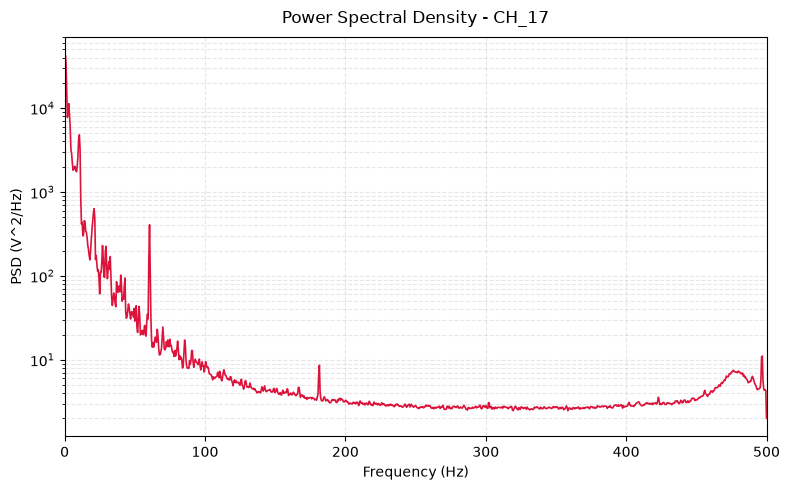

In [10]:
# --- Power Spectral Density (PSD) Analysis ---
from scipy import signal

channel_id = '17'
channel_index = channel_id_to_index[channel_id]
channel_data = signal_data_cpu[channel_index]
nperseg_val = int(fs * 2)

frequencies, psd = signal.welch(channel_data, fs=fs, nperseg=nperseg_val)

plt.figure(figsize=(8, 5))
plt.semilogy(frequencies, psd, color='crimson', linewidth=1.2)
plt.title(f'Power Spectral Density - CH_{channel_id}', fontsize=12, pad=10)
plt.xlabel('Frequency (Hz)', fontsize=10)
plt.ylabel('PSD (V^2/Hz)', fontsize=10)
plt.xlim(0, 500)
plt.grid(True, which='both', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

### Apply Notch Filter (60 Hz & 180 Hz) on a Specific Channel

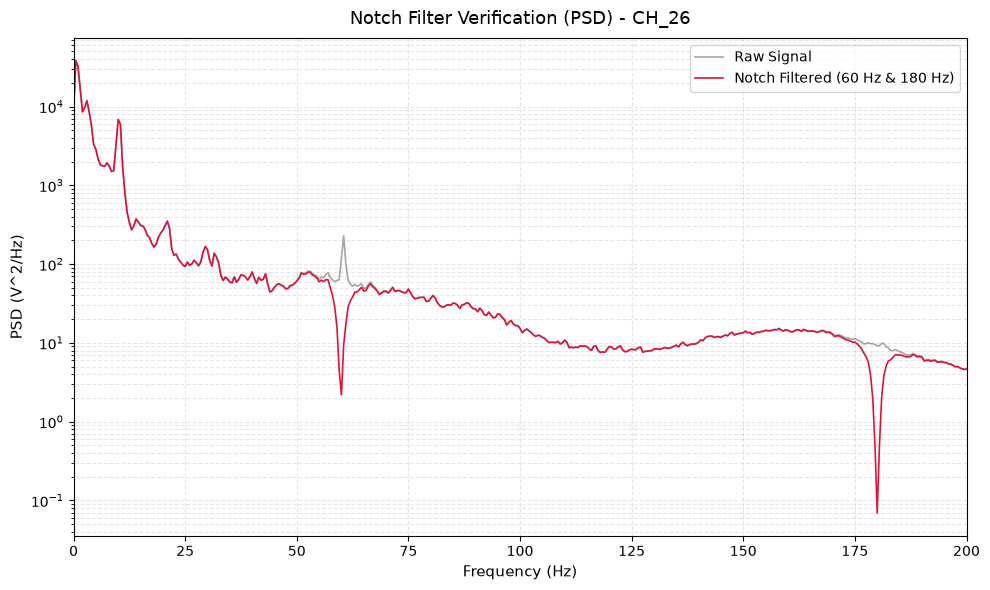

In [195]:
# Select a physical channel ID from analog_signal.array_annotations.
target_channel_id = '26'
target_channel_index = channel_id_to_index[target_channel_id]
channel_raw = signal_data_cpu[target_channel_index]

# Design Notch Filter for 60 Hz (Standard aggressiveness)
b60, a60 = iirnotch(w0=60.0, Q=30.0, fs=fs)
# Design Notch Filter for 180 Hz (Less aggressive than 60Hz)
b180, a180 = iirnotch(w0=180.0, Q=80.0, fs=fs)

# Apply both filters sequentially to the raw signal
channel_filtered_60 = filtfilt(b60, a60, channel_raw)
channel_notch_final = filtfilt(b180, a180, channel_filtered_60)

nperseg_val = int(fs * 2)
freqs_raw, psd_raw = welch(channel_raw, fs=fs, nperseg=nperseg_val)
freqs_filt, psd_filt = welch(channel_notch_final, fs=fs, nperseg=nperseg_val)

plt.figure(figsize=(10, 6))
plt.semilogy(freqs_raw, psd_raw, color='gray', alpha=0.7, linewidth=1.2, label='Raw Signal')
plt.semilogy(freqs_filt, psd_filt, color='crimson', linewidth=1.2, label='Notch Filtered (60 Hz & 180 Hz)')
plt.title(f'Notch Filter Verification (PSD) - CH_{target_channel_id}', fontsize=13, pad=10)
plt.xlabel('Frequency (Hz)', fontsize=11)
plt.ylabel('PSD (V^2/Hz)', fontsize=11)
plt.xlim(0, 200)
plt.grid(True, which='both', alpha=0.3, linestyle='--')
plt.legend(loc='upper right', fontsize=10)
plt.tight_layout()
plt.show()

Multi-Channel Notch Filtering (60 Hz & 180 Hz)

In [196]:
# Bring data back to CPU for sequential processing
n_voltage_channels = 32

# Design Notch Filters
b60, a60 = iirnotch(w0=60.0, Q=30.0, fs=fs)   # Standard aggressiveness
b180, a180 = iirnotch(w0=180.0, Q=60.0, fs=fs) # Half as aggressive (Narrower)

# Pre-allocate array for filtered signals (only for the 32 real voltage channels)
notch_data_cpu = np.zeros((n_voltage_channels, signal_data_cpu.shape[1]))

print("Applying Notch filters (60Hz and 180Hz) to all 32 voltage channels...")
for ch_idx in range(n_voltage_channels):
    ch_filt60 = filtfilt(b60, a60, signal_data_cpu[ch_idx, :])
    notch_data_cpu[ch_idx, :] = filtfilt(b180, a180, ch_filt60)

print("Filtering complete.")


Applying Notch filters (60Hz and 180Hz) to all 32 voltage channels...
Filtering complete.


### Automatic Determination of the CA1 Pyramidal Layer Channel

Based in Lopes dos Santos et al., 2025

Calculate and Plot Absolute Ripple Power

Computing spectral metrics for 32 channels

=== PYRAMIDAL LAYER CHANNEL DETERMINATION ===
Green Bar -> Reference Channel: CH_26 (Score: 0.6806)
Red Bar -> Worst Quality Channel: CH_28 (Score: 0.4666)


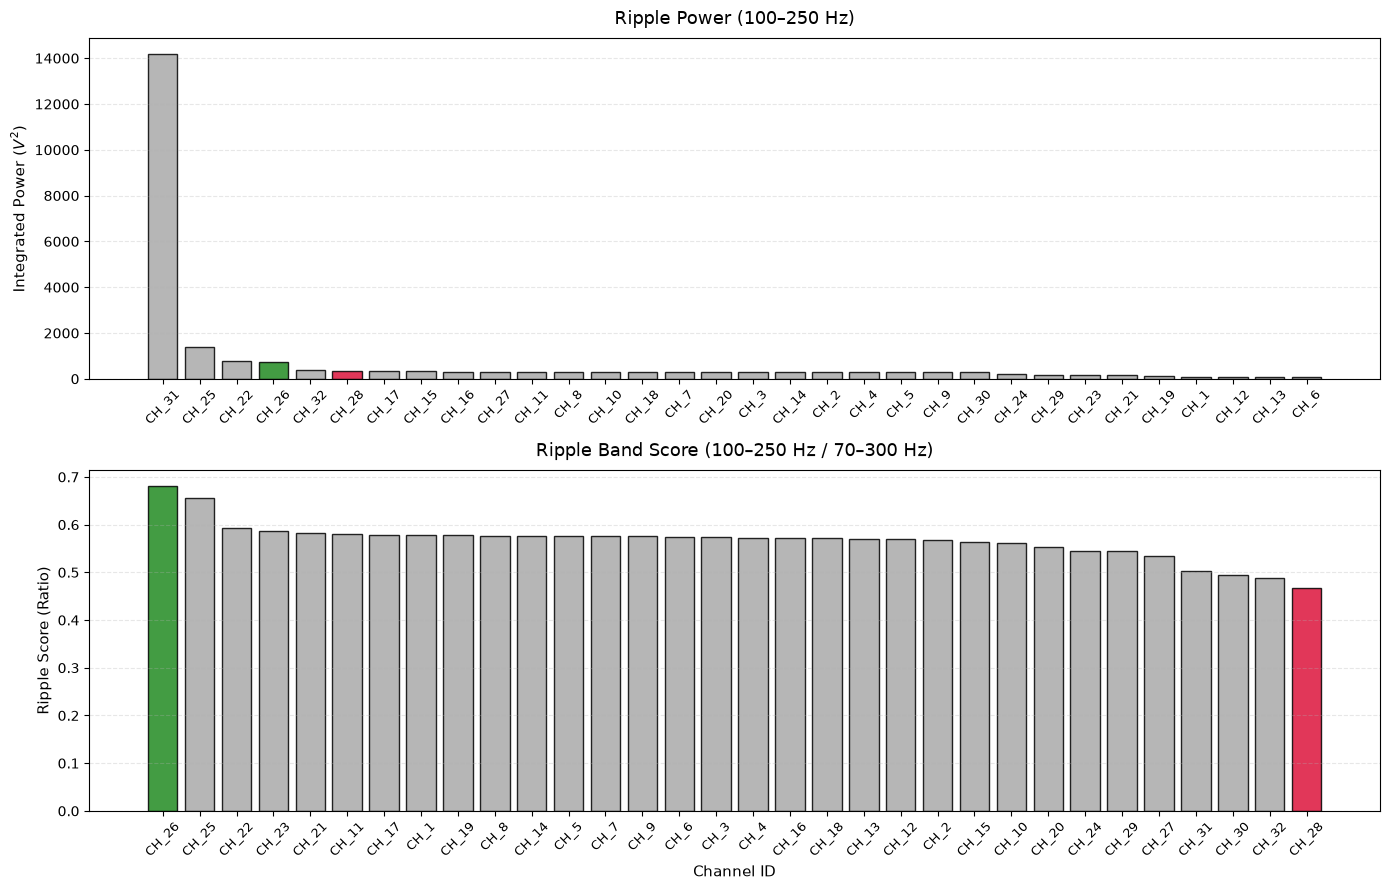

In [ ]:
t_start, t_stop = 0, 300  # seconds
offset_value = 2500

start = int(t_start * fs)
stop = int(t_stop * fs)
t = np.arange(start, stop) / fs

filtered_data_cpu = notch_data_cpu[:, start:stop]

# Welch periodogram parameters
window_seconds = 4
nperseg = int(window_seconds * fs)  # 4-second window
noverlap = int(nperseg / 2)         # 50% overlap

channel_indices = np.arange(n_voltage_channels)
ripple_powers = []
ripple_scores = []

print('Computing spectral metrics for 32 channels')

for channel_index in channel_indices:
    frequencies, psd = welch(
        filtered_data_cpu[channel_index],
        fs=fs,
        window='hann',
        nperseg=nperseg,
        noverlap=noverlap
    )
    ripple_mask = (frequencies >= 100) & (frequencies <= 250)
    surrounding_mask = (frequencies >= 70) & (frequencies <= 300)
    ripple_power = np.trapezoid(psd[ripple_mask], frequencies[ripple_mask])
    surrounding_power = np.trapezoid(
        psd[surrounding_mask], frequencies[surrounding_mask]
    )
    score = ripple_power / surrounding_power if surrounding_power > 0 else 0
    ripple_powers.append(ripple_power)
    ripple_scores.append(score)

ripple_powers = np.array(ripple_powers)
ripple_scores = np.array(ripple_scores)
highest_score_index = np.argmax(ripple_scores)
lowest_score_index = np.argmin(ripple_scores)
highest_score_channel_index = channel_indices[highest_score_index]
lowest_score_channel_index = channel_indices[lowest_score_index]

channel_colors = {
    channel_index: (
        'forestgreen' if channel_index == highest_score_channel_index
        else 'crimson' if channel_index == lowest_score_channel_index
        else 'darkgray'
    )
    for channel_index in channel_indices
}

power_order = np.argsort(ripple_powers)[::-1]
score_order = np.argsort(ripple_scores)[::-1]
sorted_power_indices = channel_indices[power_order]
sorted_score_indices = channel_indices[score_order]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), sharex=False)
x_positions = np.arange(n_voltage_channels)

ax1.bar(
    x_positions,
    ripple_powers[power_order],
    color=[channel_colors[index] for index in sorted_power_indices],
    edgecolor='black',
    alpha=0.85
)
ax1.set_title('Ripple Power (100–250 Hz)', fontsize=13, pad=10)
ax1.set_ylabel('Integrated Power ($V^2$)', fontsize=11)
ax1.set_xticks(x_positions)
ax1.set_xticklabels(
    [channel_names[index] for index in sorted_power_indices],
    fontsize=9,
    rotation=45
)
ax1.grid(True, axis='y', alpha=0.3, linestyle='--')

ax2.bar(
    x_positions,
    ripple_scores[score_order],
    color=[channel_colors[index] for index in sorted_score_indices],
    edgecolor='black',
    alpha=0.85
)
ax2.set_title('Ripple Band Score (100–250 Hz / 70–300 Hz)', fontsize=13, pad=10)
ax2.set_xlabel('Channel ID', fontsize=11)
ax2.set_ylabel('Ripple Score (Ratio)', fontsize=11)
ax2.set_xticks(x_positions)
ax2.set_xticklabels(
    [channel_names[index] for index in sorted_score_indices],
    fontsize=9,
    rotation=45
)
ax2.grid(True, axis='y', alpha=0.3, linestyle='--')

hippocampus_channel = filtered_data_cpu[highest_score_channel_index]

print('\n=== PYRAMIDAL LAYER CHANNEL DETERMINATION ===')
print(
    f"Green Bar -> Reference Channel: {channel_names[highest_score_channel_index]} "
    f"(Score: {ripple_scores[highest_score_index]:.4f})"
)
print(
    f"Red Bar -> Worst Quality Channel: {channel_names[lowest_score_channel_index]} "
    f"(Score: {ripple_scores[lowest_score_index]:.4f})"
)

plt.tight_layout()
plt.show()

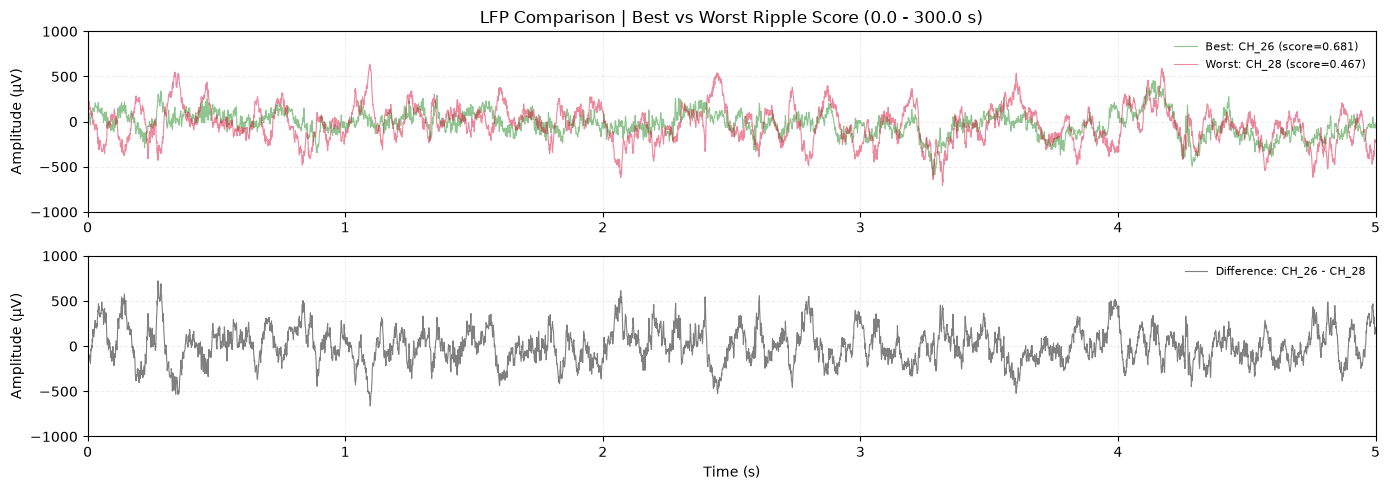

In [199]:
# --- Best vs Worst Ripple Score: LFP Comparison ---
best = filtered_data_cpu[highest_score_channel_index]
worst = filtered_data_cpu[lowest_score_channel_index]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5))
ax1.plot(t, best, lw=0.8, alpha=0.5, color='forestgreen',
        label=f'Best: {channel_names[highest_score_channel_index]} '
              f'(score={ripple_scores[highest_score_index]:.3f})')

ax1.plot(t, worst, lw=0.8, alpha=0.5, color='crimson',
        label=f'Worst: {channel_names[lowest_score_channel_index]} '
              f'(score={ripple_scores[lowest_score_index]:.3f})')

ax1.set_title(f'LFP Comparison | Best vs Worst Ripple Score ({t_start:.1f} - {t_stop:.1f} s)')
ax1.set_ylabel('Amplitude (µV)')
ax1.set_xlim(0, 5)
ax1.set_ylim(-1000,1000)
ax1.grid(True, alpha=0.2, linestyle='--')
ax1.legend(frameon=False, fontsize=8)

ax2.plot(t, best - worst, lw=0.8, alpha=0.5, color='black',
        label=f'Difference: {channel_names[highest_score_channel_index]} - '
              f'{channel_names[lowest_score_channel_index]}')

ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Amplitude (µV)')
ax2.set_xlim(0,5)
ax2.set_ylim(-1000,1000)
ax2.grid(True, alpha=0.2, linestyle='--')
ax2.legend(frameon=False, fontsize=8)

plt.tight_layout()
plt.show()

### SWR Detection

Based in Lopes dos Santos et al., 2025

In [200]:
def compute_swr_metrics(lfp_channel, fs=1000):
    time = np.linspace(0, len(lfp_channel)/fs, len(lfp_channel))
    
    # Bandpass filtering (Ripple 100-250 Hz and Control band adjusted for fs=1000Hz)
    b_ripple, a_ripple = butter(4, [100, 250], btype='bandpass', fs=fs)
    ripple_band = filtfilt(b_ripple, a_ripple, lfp_channel)
    
    # Control band adjusted to 250-450 Hz because Nyquist limit is 500 Hz
    b_ctrl, a_ctrl = butter(4, [250, 450], btype='bandpass', fs=fs)
    control_band = filtfilt(b_ctrl, a_ctrl, lfp_channel)
    
    # Hilbert transform for instantaneous envelopes and phase
    analytic_ripple = hilbert(ripple_band)
    envelope = np.abs(analytic_ripple)
    phase_unwrapped = np.unwrap(np.angle(analytic_ripple))
    
    ctrl_envelope = np.abs(hilbert(control_band))
    
    # Detection thresholds
    median_env = np.median(envelope)
    threshold = 3 * median_env
    half_threshold = 1.5 * median_env
    
    # Peak detection (retaining only the highest peak within 20ms frames)
    min_distance_samples = int(0.020 * fs) 
    peaks, _ = find_peaks(envelope, height=threshold, distance=min_distance_samples)
    
    candidate_events = []
    
    # Feature extraction per candidate event
    for peak in peaks:
        onset, offset = peak, peak
        while onset > 0 and envelope[onset] >= half_threshold: onset -= 1
        while offset < len(envelope) - 1 and envelope[offset] >= half_threshold: offset += 1
            
        duration = (offset - onset) / fs
        if duration <= 0: continue
            
        phase_diff_deg = np.degrees(phase_unwrapped[offset] - phase_unwrapped[onset])
        cycles = phase_diff_deg / 360.0
        mean_freq = cycles / duration
        
        ripple_power = (np.mean(envelope[onset:offset])) ** 2
        ctrl_power = (np.mean(ctrl_envelope[onset:offset])) ** 2
        
        # Validation checks
        check_2 = mean_freq > 100
        check_3 = cycles >= 4
        check_4 = ripple_power >= (1.5 * ctrl_power)
        
        is_valid_swr = check_2 and check_3 and check_4
        
        candidate_events.append({
            'Peak_Sample': peak,
            'Onset_Time(s)': time[onset],
            'Offset_Time(s)': time[offset],
            'Duration(s)': duration,
            'Cycles': cycles,
            'Mean_Freq(Hz)': mean_freq,
            'Ripple_Power': ripple_power,
            'Ctrl_Power': ctrl_power,
            'Is_Valid_SWR': is_valid_swr
        })
        
    return pd.DataFrame(candidate_events), ripple_band, envelope

In [201]:
# Process the signal using the defined single-channel algorithm
df_events, ripple_band, envelope = compute_swr_metrics(best[start:stop] - worst[start:stop], fs=fs)

# Print detection summaries
print(f"Total candidate events detected (exceeded 5x median): {len(df_events)}")

# Filter true SWR events that pass the remaining 3 strict criteria
true_swrs = df_events[df_events['Is_Valid_SWR'] == True].copy()
print(f"Validated SWR events (passed all remaining criteria): {len(true_swrs)}")

print("\n=== SWR EVENTS DATAFRAME PREVIEW ===")
display(true_swrs.head(10))

Total candidate events detected (exceeded 5x median): 527
Validated SWR events (passed all remaining criteria): 157

=== SWR EVENTS DATAFRAME PREVIEW ===


,Peak_Sample,Onset_Time(s),Offset_Time(s),Duration(s),Cycles,Mean_Freq(Hz),Ripple_Power,Ctrl_Power,Is_Valid_SWR
1,443,0.434001,0.474002,0.040,6.120533,153.013324,10035.354358,299.581222,True
2,467,0.434001,0.474002,0.040,6.120533,153.013324,10035.354358,299.581222,True
4,1751,1.735006,1.768006,0.033,5.244040,158.910294,7888.886116,324.569375,True
6,2179,2.173007,2.199007,0.026,4.144043,159.386270,6794.984705,784.791051,True
7,2299,2.265008,2.306008,0.041,6.326931,154.315386,10759.465653,339.664931,True
14,4266,4.256014,4.283014,0.027,4.148545,153.649826,18311.992741,255.355797,True
15,5146,5.137017,5.164017,0.027,4.339307,160.715090,10043.941520,466.190129,True
21,8217,8.206027,8.233027,0.027,4.076496,150.981320,13942.830145,99.894990,True
23,10851,10.830036,10.860036,0.030,4.639174,154.639144,6591.810260,725.118206,True
26,12285,12.271041,12.305041,0.034,5.048177,148.475805,17369.345279,337.984815,True


In [202]:
def compute_morlet_power(signal, fs, frequency_range=(80, 270),
                         frequency_step=1.0, center_frequency=2.0, bandwidth=2.0):
    x = signal.to_numpy() if isinstance(signal, pd.Series) else np.asarray(signal)
    x = x - np.mean(x)
    dt = 1 / fs
    freqs = np.arange(frequency_range[0], frequency_range[1] + frequency_step, frequency_step)
    scales = center_frequency / (freqs * dt)

    coef, cwt_freqs = pywt.cwt(
        x, scales, f'cmor{bandwidth}-{center_frequency}',
        method='fft', sampling_period=dt
    )
    power = np.abs(coef) ** 2
    order = np.argsort(cwt_freqs)
    return cwt_freqs[order], power[order]


def draw_morlet_spectrogram(ax, power, freqs, time, ripple_band=(100, 250),
                            color_limits=(-3, 9), baseline_seconds=0.15):
    # Baseline normalization
    baseline = np.abs(time) >= baseline_seconds
    baseline_power = np.median(power[:, baseline], axis=1, keepdims=True)
    power_db = 10 * np.log10(power / np.maximum(baseline_power, np.finfo(float).tiny))
    power_db = np.clip(power_db, *color_limits)

    ax.pcolormesh(
        time, freqs, power_db, shading='nearest', cmap='jet',
        vmin=color_limits[0], vmax=color_limits[1], rasterized=True
    )
    ax.set_ylim(*ripple_band)


def plot_ripple_events(df_all, ripple_times, fs=1000, start_ripple=0,
                       n_ripples=5, height=None, frequency_range=(100, 250),
                       color_limits=(-3, 9)):
    if ripple_times.empty:
        print("No ripple events to plot.")
        return

    ripples = ripple_times.iloc[start_ripple:start_ripple + n_ripples]
    if ripples.empty:
        print(f"No ripples found from index {start_ripple}.")
        return

    window, display_range = 0.8, (-0.25, 0.25)
    n = len(ripples)

    fig, axes = plt.subplots(
        3, n, figsize=(3.4 * n, 6), squeeze=False,
        sharex='all', sharey='row',
        gridspec_kw={'height_ratios': [0.7, 0.7, 1.6]}
    )

    for i, (_, event) in enumerate(ripples.iterrows()):
        center = (event['Onset_Time(s)'] + event['Offset_Time(s)']) / 2
        data = df_all[df_all['time'].between(
            center - window / 2, center + window / 2
        )].copy()
        if data.empty:
            continue

        data['relative_time'] = data['time'] - center
        t = data['relative_time'].to_numpy()
        raw_ax, filt_ax, spec_ax = axes[:, i]

        # Raw: center and scale each ripple independently
        raw = data['Raw'].to_numpy()
        visible = (t >= display_range[0]) & (t <= display_range[1])
        raw_visible = raw[visible]
        raw_center = (raw_visible.max() + raw_visible.min()) / 2
        raw_range = np.ptp(raw_visible) / 2
        raw_range = max(raw_range * 1.8, np.finfo(float).eps)

        raw_ax.plot(t, raw - raw_center, color='black', lw=0.6)
        raw_ax.set_ylim(-raw_range, raw_range)
        raw_ax.axhline(0, color='gray', lw=0.4, alpha=0.4)

        # Filtered signal + envelope
        filt_ax.plot(t, data['Filtered'], color='purple', lw=0.6, label='Filtered')
        filt_ax.plot(t, data['Envelope'], color='darkorange', lw=0.9, label='Envelope')

        if height is not None:
            filt_ax.axhline(height, color='darkorange', ls='--', lw=0.7)
            filt_ax.axhline(height / 2, color='orange', ls='--', lw=0.7)

        # Morlet spectrogram
        freqs, power = compute_morlet_power(data['Filtered'], fs, frequency_range)
        draw_morlet_spectrogram(
            spec_ax, power, freqs, t,
            ripple_band=(100, 250), color_limits=color_limits
        )

        # Mark event on Raw and Filtered only
        onset = event['Onset_Time(s)'] - center
        offset = event['Offset_Time(s)'] - center
        for ax in (raw_ax, filt_ax):
            ax.axvspan(onset, offset, color='gray', alpha=0.25, lw=0)

        for ax in axes[:, i]:
            ax.set_xlim(display_range)
            ax.tick_params(labelsize=7)
            ax.spines[['top', 'right']].set_visible(False)

        raw_ax.set_title(
            f'Ripple {start_ripple + i} | {event["Onset_Time(s)"]:.2f} s',
            fontsize=10
        )

        if i == 0:
            raw_ax.set_ylabel('Raw', fontsize=8)
            filt_ax.set_ylabel('Filtered / Envelope', fontsize=8)
            spec_ax.set_ylabel('Frequency (Hz)', fontsize=8)

        spec_ax.set_xlabel('Relative time (s)', fontsize=8)

    axes[1, 0].legend(loc='upper right', fontsize=6, frameon=False)
    fig.suptitle(f'Ripples {start_ripple}–{start_ripple + n - 1}', fontsize=11)
    fig.tight_layout(rect=(0, 0, 1, 0.94))
    plt.show()

Plotting ripples 5 to 9...


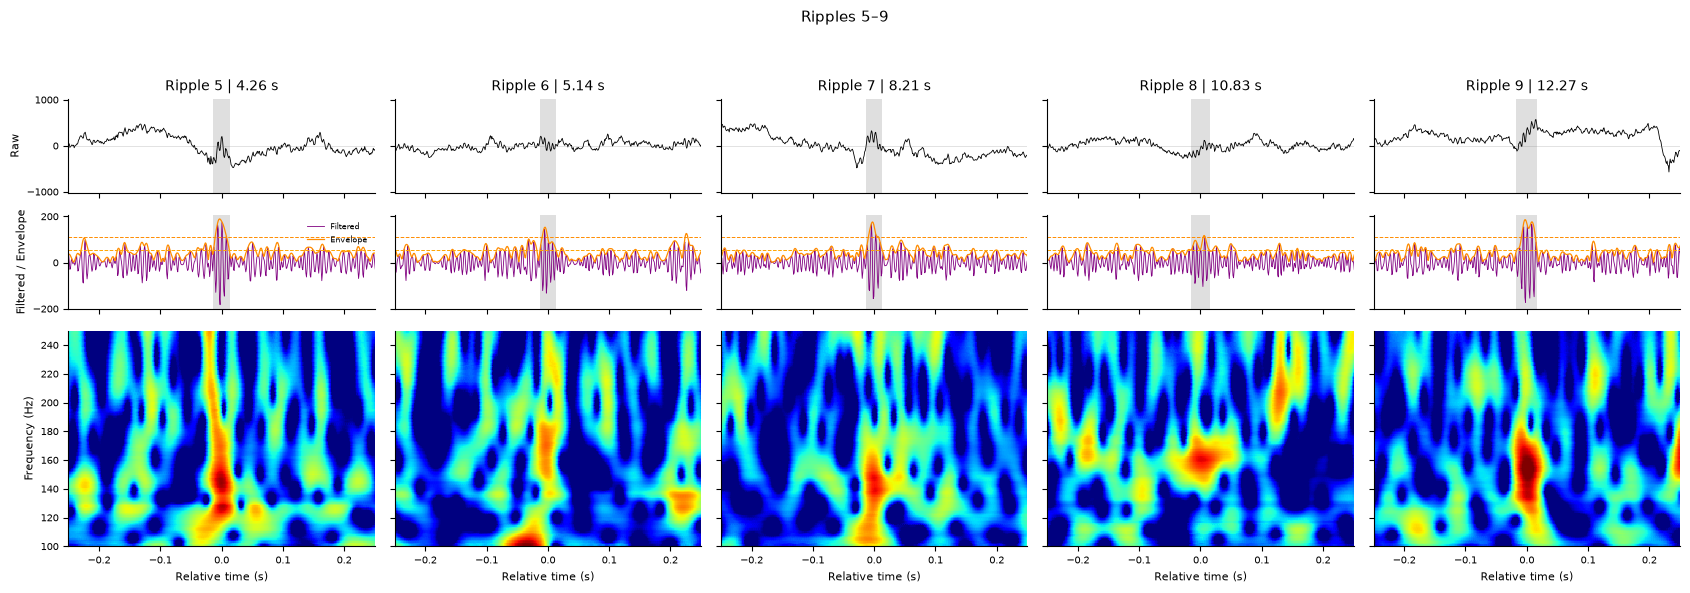

In [206]:
# Build the signal table for plotting.
time_array = np.arange(len(best)) / fs

df_full_signals = pd.DataFrame({
    'time': time_array,
    'Raw': best,
    'Filtered': ripple_band,
    'Envelope': envelope
})

detection_threshold = 3 * np.median(envelope)

# Choose the first ripple and how many consecutive ripples to inspect.
start_ripple = 5
n_ripples = 5

if len(true_swrs) > 0:
    print(
        f'Plotting ripples {start_ripple} to '
        f'{start_ripple + min(n_ripples, len(true_swrs)) - 1}...'
    )
    plot_ripple_events(
        df_full_signals,
        true_swrs,
        fs=fs,
        start_ripple=start_ripple,
        n_ripples=n_ripples,
        height=detection_threshold,
        frequency_range=(100, 250),
        color_limits=(-4, 16)
    )
else:
    print('Cannot plot events: no validated SWR events were detected.')

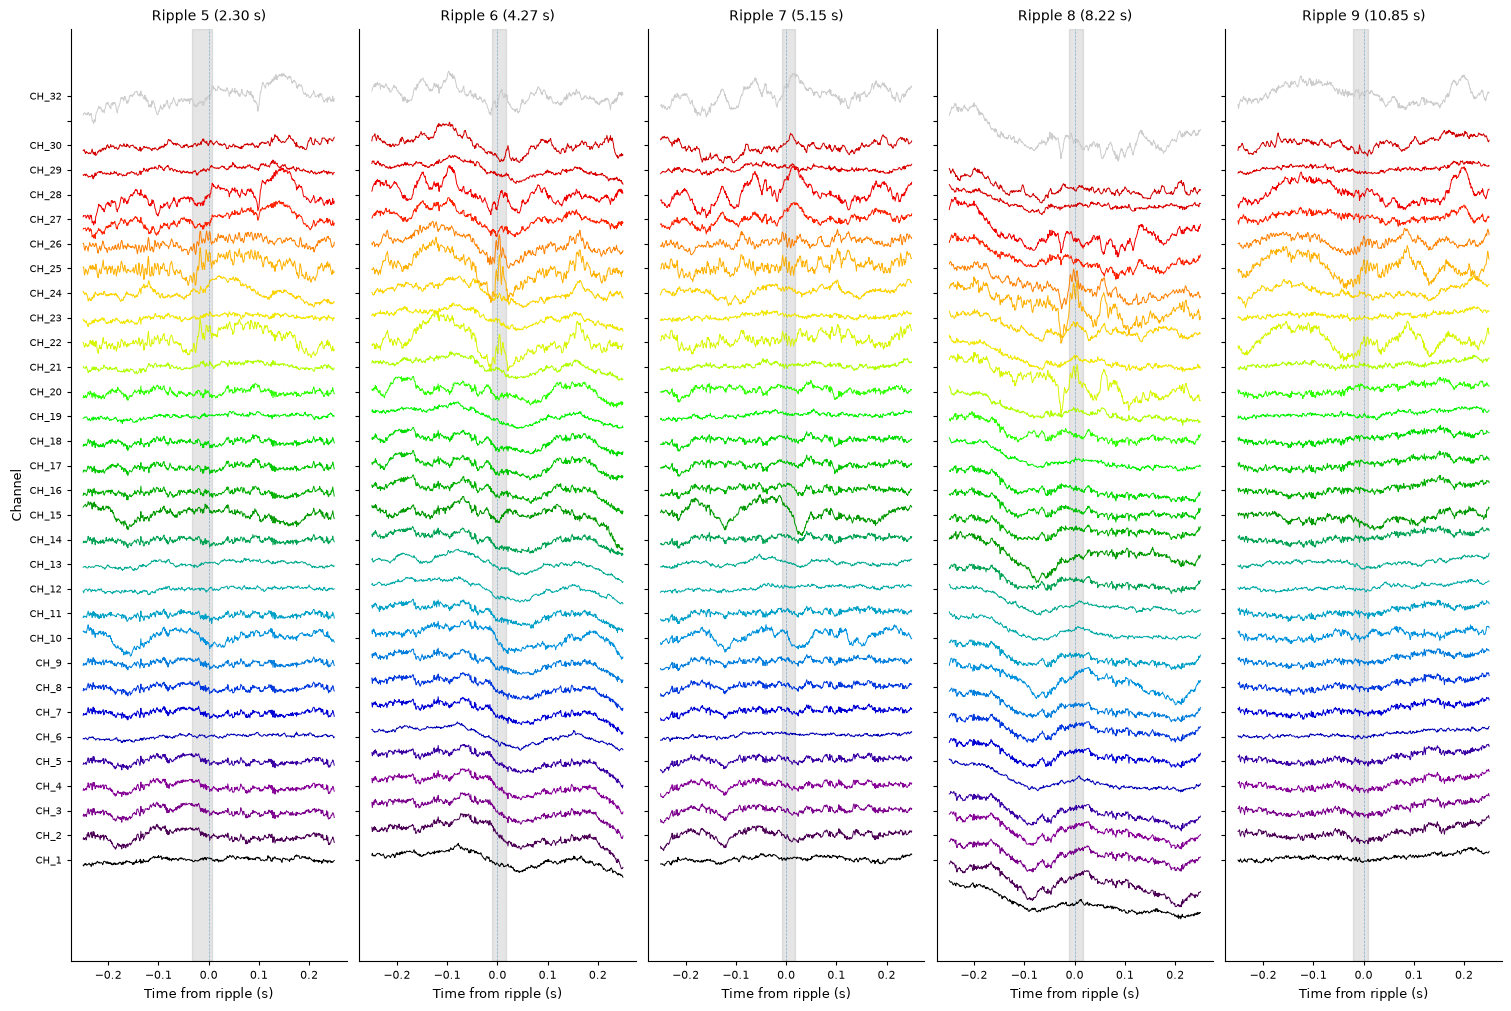

In [207]:
# Plot selected ripples, excluding noisy channels.
start_ripple, n_events = 5, 5
window, spacing = 0.25, 500
skip_channel_ids = {'31'}
offsets = np.arange(n_voltage_channels) * spacing

events = true_swrs.iloc[start_ripple - 1:start_ripple - 1 + n_events]
fig, axes = plt.subplots(1, len(events), figsize=(3 * n_events, 10), sharey=True, constrained_layout=True)
axes = np.atleast_1d(axes)

for plot_index, (_, event) in enumerate(events.iterrows()):
    center = event['Peak_Sample'] / fs
    mask = (time_array >= center - window) & (time_array <= center + window)
    relative_time = time_array[mask] - center

    for channel_index in range(n_voltage_channels):
        channel_id = channel_ids[channel_index]
        if channel_id not in skip_channel_ids:
            axes[plot_index].plot(
                relative_time,
                filtered_data_cpu[channel_index, mask] + offsets[channel_index],
                lw=0.7,
                color=colors[channel_index]
            )

    axes[plot_index].axvspan(
        event['Onset_Time(s)'] - center,
        event['Offset_Time(s)'] - center,
        color='gray',
        alpha=0.2
    )
    axes[plot_index].axvline(0, ls='--', lw=0.5, alpha=0.5)
    axes[plot_index].set_title(
        f"Ripple {start_ripple + plot_index} ({center:.2f} s)",
        fontsize=10
    )
    axes[plot_index].set_xlabel('Time from ripple (s)', fontsize=9)
    axes[plot_index].spines[['top', 'right']].set_visible(False)
    axes[plot_index].tick_params(labelsize=8, length=3)

axes[0].set_yticks(offsets)
axes[0].set_yticklabels(
    [
        channel_names[channel_index] if channel_ids[channel_index] not in skip_channel_ids else ''
        for channel_index in range(n_voltage_channels)
    ],
    fontsize=7
)
axes[0].set_ylabel('Channel', fontsize=9)
plt.show()